# 3.4 News: Sentiment Analysis

Data: **229 000+ articles** from MediaCloud, Jul–Nov 2024, stored in `2_Silver`.

Three sentiment methods applied to article headlines:

| # | Method | Type | Output |
|---|---|---|---|
| 1 | **VADER** | Rule-based lexicon | `vader_compound` ∈ [−1, +1] |
| 2 | **TextBlob** | Pattern lexicon | `tb_polarity` ∈ [−1, +1], `tb_subjectivity` ∈ [0, 1] |
| 3 | **NRCLex** | Emotion lexicon | 8 emotion dimensions |

**Predictive features saved:** VADER + NRCLex (daily × leaning aggregates).

**Input:** `Data/2_Silver/Newspapers/mediacloud_articles_clean.csv`  
**Output:** `Data/2_Silver/Newspapers/sentiment_features_newspapers.csv`

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ── House style ──────────────────────────────────────────────────────────────
sys.path.insert(0, os.path.abspath('../..'))
from house_style import apply_style, BG_DARK, BG_PANEL, TEXT_PRIMARY, TEXT_MUTED, ACCENT, DEMOCRAT, REPUBLICAN, EVENTS, add_events
apply_style()

import nltk
nltk.download('stopwords',                    quiet=True)
nltk.download('punkt',                        quiet=True)
nltk.download('punkt_tab',                    quiet=True)
nltk.download('averaged_perceptron_tagger',   quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nrclex import NRCLex
from transformers import pipeline
from textblob import TextBlob

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA   = Path('../../Data/2_Silver/Newspapers/mediacloud_articles_clean.csv')
SILVER = Path('../../Data/2_Silver/Newspapers')

# ── Colour & label mappings ───────────────────────────────────────────────────
LEANING_COLORS = {
    'Democratic':     DEMOCRAT,
    'Republican':     REPUBLICAN,
    'Center/Unknown': '#6B7280',
}
LEANING_SHORT = {
    'Democratic':     'dem',
    'Republican':     'rep',
    'Center/Unknown': 'cen',
}

EMOTION_COLORS = {
    'fear':         '#8B5CF6',
    'anger':        REPUBLICAN,
    'anticipation': ACCENT,
    'trust':        '#22C55E',
    'surprise':     '#06B6D4',
    'sadness':      '#60A5FA',
    'disgust':      '#84CC16',
    'joy':          '#FCD34D',
}
EMOTION_COLS = ['fear', 'anger', 'anticipation', 'trust', 'surprise', 'sadness', 'disgust', 'joy']

print('Setup complete.')


Setup complete.


# 1. Load & inspect

In [2]:
df = pd.read_csv(DATA, parse_dates=['date'])

print(f'Total articles : {len(df):,}')
print(f'Date range     : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Unique sources : {df["source"].nunique()}\n')
print(df.groupby('leaning').size().sort_values(ascending=False).to_string())

df.head(3)


Total articles : 229,946
Date range     : 2024-07-05 → 2024-11-04
Unique sources : 187

leaning
Center/Unknown    99517
Democratic        82712
Republican        47717


,source,leaning,date,title,url,detected_lang,title_clean,words,word_count,week
0,Syracuse.com,Center/Unknown,2024-07-05,5 candidates who could replace Biden as 2024 D...,https://www.syracuse.com/us-news/2024/07/5-can...,en,candidates could replace biden democratic pres...,"['candidates', 'could', 'replace', 'biden', 'd...",7,2024-07-01
1,CNN,Democratic,2024-07-05,What to expect from the June jobs report,https://www.cnn.com/2024/07/05/economy/june-jo...,en,expect june jobs report,"['expect', 'june', 'jobs', 'report']",4,2024-07-01
2,NBC News,Democratic,2024-07-05,Iran holds runoff presidential vote pitting ha...,https://www.nbcnews.com/news/world/iran-presid...,en,iran holds runoff presidential vote pitting ha...,"['iran', 'holds', 'runoff', 'presidential', 'v...",12,2024-07-01


In [3]:
# Drop rows without a cleaned title; keep only the three main leanings
df = df.dropna(subset=['title_clean']).copy()
df = df[df['leaning'].isin(LEANING_COLORS)].copy()
df = df.sort_values('date').reset_index(drop=True)

print(f'Articles after cleaning : {len(df):,}')
print(df['leaning'].value_counts().to_string())


Articles after cleaning : 229,943
leaning
Center/Unknown    99517
Democratic        82711
Republican        47715


# 2. VADER Sentiment Analysis

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based model that handles
capitalisation, punctuation, negations, and degree modifiers — well suited for short news
headlines (following **Lecture 4 — Traditional Sentiment Analysis**).

Output columns:
- `vader_compound` — normalised composite score ∈ [−1, 1]
- `vader_pos`, `vader_neg`, `vader_neu` — proportional scores

Classification thresholds (standard VADER convention):
- **positive** : compound ≥ 0.05
- **negative** : compound ≤ −0.05
- **neutral**  : −0.05 < compound < 0.05

In [4]:
vader = SentimentIntensityAnalyzer()

def vader_scores(text):
    scores = vader.polarity_scores(str(text))
    return scores['compound'], scores['pos'], scores['neg'], scores['neu']

(
    df['vader_compound'],
    df['vader_pos'],
    df['vader_neg'],
    df['vader_neu'],
) = zip(*df['title_clean'].map(vader_scores))

# Classify as positive / negative / neutral (standard VADER thresholds)
def vader_label(compound):
    if compound >=  0.05: return 'positive'
    if compound <= -0.05: return 'negative'
    return 'neutral'

df['vader_label'] = df['vader_compound'].map(vader_label)

print('VADER score distribution (overall):')
print(df['vader_label'].value_counts(normalize=True).mul(100).round(1).to_string())
print(f'\nMean compound score : {df["vader_compound"].mean():+.4f}')
print(f'Std  compound score : {df["vader_compound"].std():.4f}')

VADER score distribution (overall):
vader_label
negative    36.0
neutral     36.0
positive    28.0

Mean compound score : -0.0525
Std  compound score : 0.3837


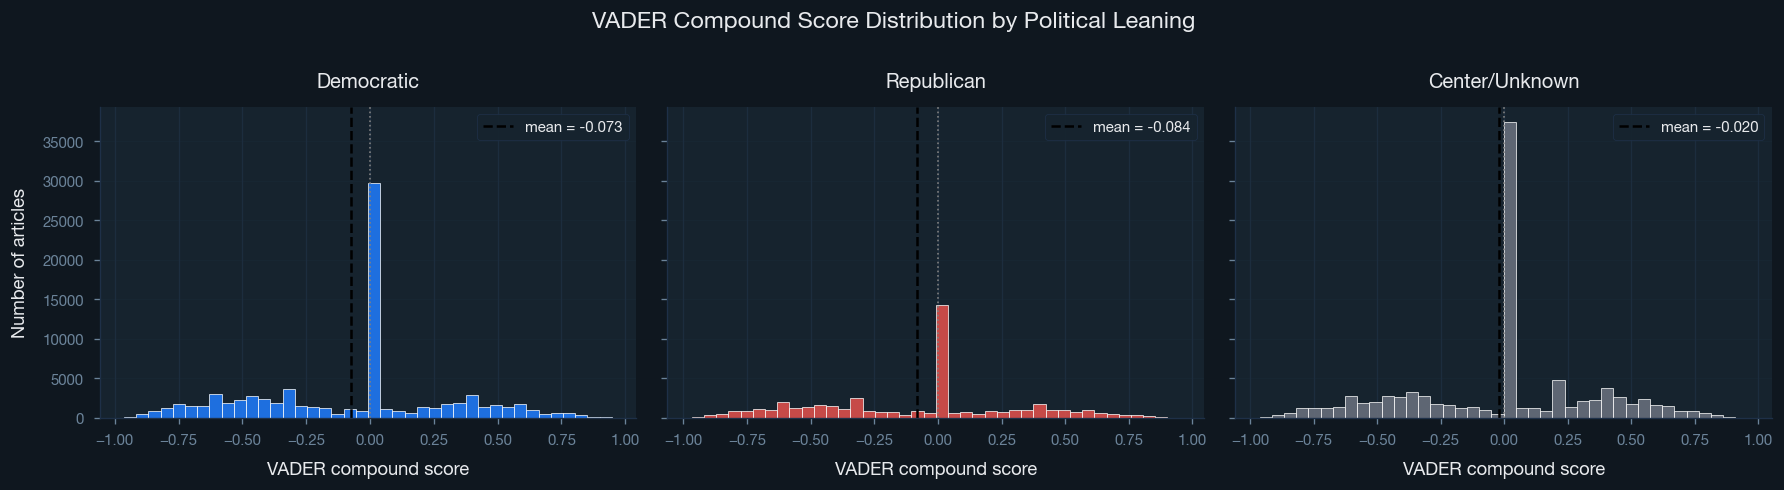

In [5]:
# ── Distribution of compound scores by leaning ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (leaning, color) in zip(axes, LEANING_COLORS.items()):
    sub = df[df['leaning'] == leaning]['vader_compound']
    ax.hist(sub, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(sub.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'mean = {sub.mean():+.3f}')
    ax.axvline(0, color='grey', linestyle=':', linewidth=1)
    ax.set_title(leaning, fontsize=12, fontweight='bold')
    ax.set_xlabel('VADER compound score')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Number of articles')
fig.suptitle('VADER Compound Score Distribution by Political Leaning',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

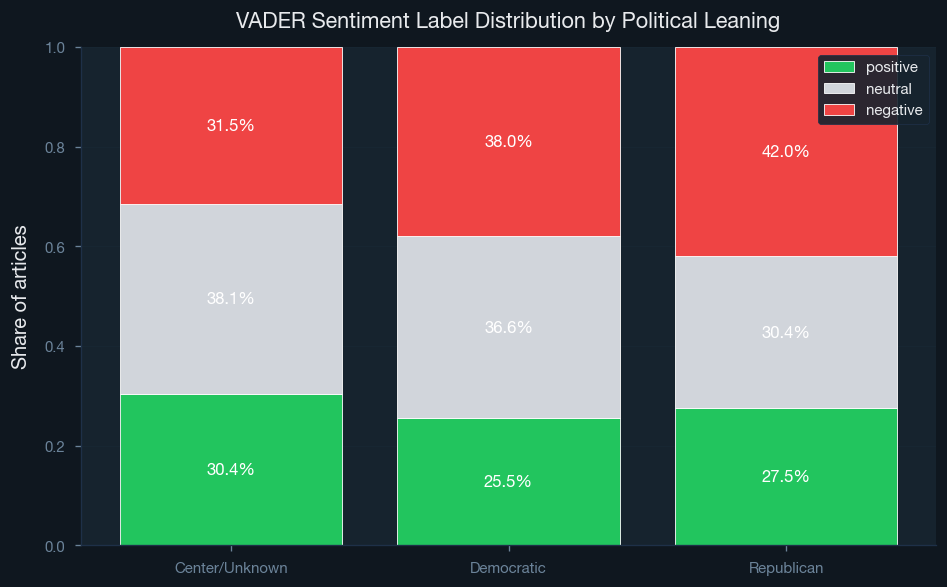

In [6]:
# ── Sentiment label shares per leaning (stacked bar) ─────────────────────────
label_shares = (
    df.groupby(['leaning', 'vader_label'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
    [['positive', 'neutral', 'negative']]
)

fig, ax = plt.subplots(figsize=(8, 5))
label_colors = {'positive': '#22C55E', 'neutral': '#D1D5DB', 'negative': '#EF4444'}

bottom = np.zeros(len(label_shares))
for label, col in label_colors.items():
    values = label_shares[label].values
    bars = ax.bar(label_shares.index, values, bottom=bottom, color=col,
                  label=label, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        if val > 0.04:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.1%}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
    bottom += values

ax.set_ylabel('Share of articles', fontsize=12)
ax.set_title('VADER Sentiment Label Distribution by Political Leaning',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

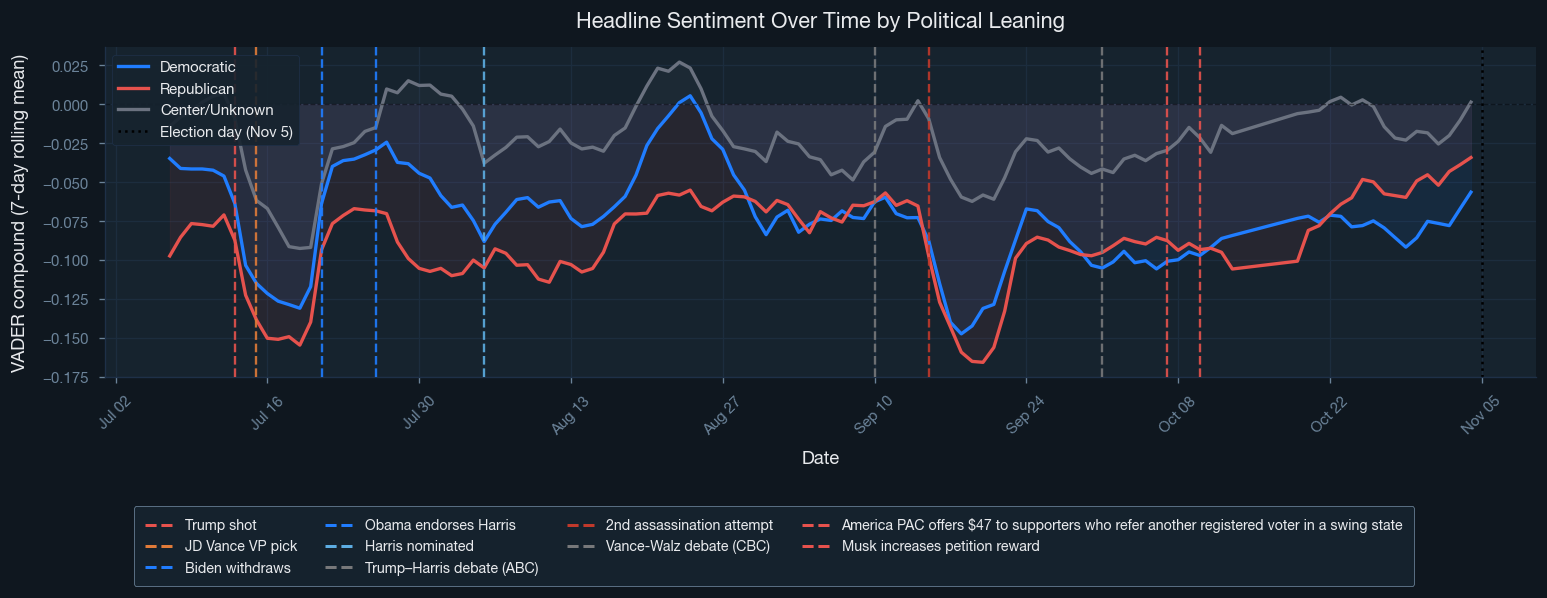

In [7]:
# ── VADER compound score over time (7-day rolling mean) ──────────────────────
daily_vader = (
    df.groupby(['date', 'leaning'])['vader_compound']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))

for leaning, color in LEANING_COLORS.items():
    sub = daily_vader[daily_vader['leaning'] == leaning].set_index('date')
    rolled = sub['vader_compound'].rolling(7, min_periods=3).mean()
    ax.plot(rolled.index, rolled.values, color=color, linewidth=2, label=leaning)
    ax.fill_between(rolled.index, rolled.values, 0, color=color, alpha=0.08)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
add_events(ax)
ax.axvline(pd.Timestamp('2024-11-05'), color='black', linestyle=':',
           linewidth=1.5, label='Election day (Nov 5)')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('VADER compound (7-day rolling mean)', fontsize=11)
ax.set_title('Headline Sentiment Over Time by Political Leaning',
             fontsize=13, fontweight='bold')
import matplotlib.lines as mlines
data_handles = ax.get_legend_handles_labels()
event_handles = [
    mlines.Line2D([], [], color=c, linestyle='--', linewidth=1.8, label=lbl)
    for lbl, _, c in EVENTS
]
ax.legend(handles=data_handles[0], labels=data_handles[1], loc='upper left')
fig.legend(
    handles=event_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    ncol=min(len(EVENTS), 4),
    facecolor=BG_PANEL, edgecolor=TEXT_MUTED, labelcolor=TEXT_PRIMARY,
    fontsize=8.5, framealpha=0.95, borderpad=0.8,
)
plt.tight_layout(rect=[0, 0.18, 1, 1])
plt.show()

---
## 4. TextBlob

**What it is:** TextBlob uses the Pattern library lexicon to assign a polarity score
∈ [−1, +1] and a subjectivity score ∈ [0, 1] (0 = very objective, 1 = very subjective).

**Output:** `tb_polarity` (negative → positive) and `tb_subjectivity` (objective → subjective).

**Applied to:** article headlines (`title` column).

In [13]:
import nltk
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
from textblob import TextBlob

def tb_scores(text):
    blob = TextBlob(str(text))
    return blob.sentiment.polarity, blob.sentiment.subjectivity

tb_results = df['title_clean'].fillna('').apply(tb_scores)
df['tb_polarity']     = [r[0] for r in tb_results]
df['tb_subjectivity'] = [r[1] for r in tb_results]

def tb_label(p):
    if p >  0.05: return 'positive'
    if p < -0.05: return 'negative'
    return 'neutral'

df['tb_label'] = df['tb_polarity'].map(tb_label)

print('TextBlob score distribution (overall):')
print(df['tb_label'].value_counts(normalize=True).mul(100).round(1).to_string())
print(f'\nMean polarity     : {df["tb_polarity"].mean():+.4f}')
print(f'Mean subjectivity : {df["tb_subjectivity"].mean():.4f}')


TextBlob score distribution (overall):
tb_label
neutral     58.1
positive    25.5
negative    16.4

Mean polarity     : +0.0244
Mean subjectivity : 0.2605


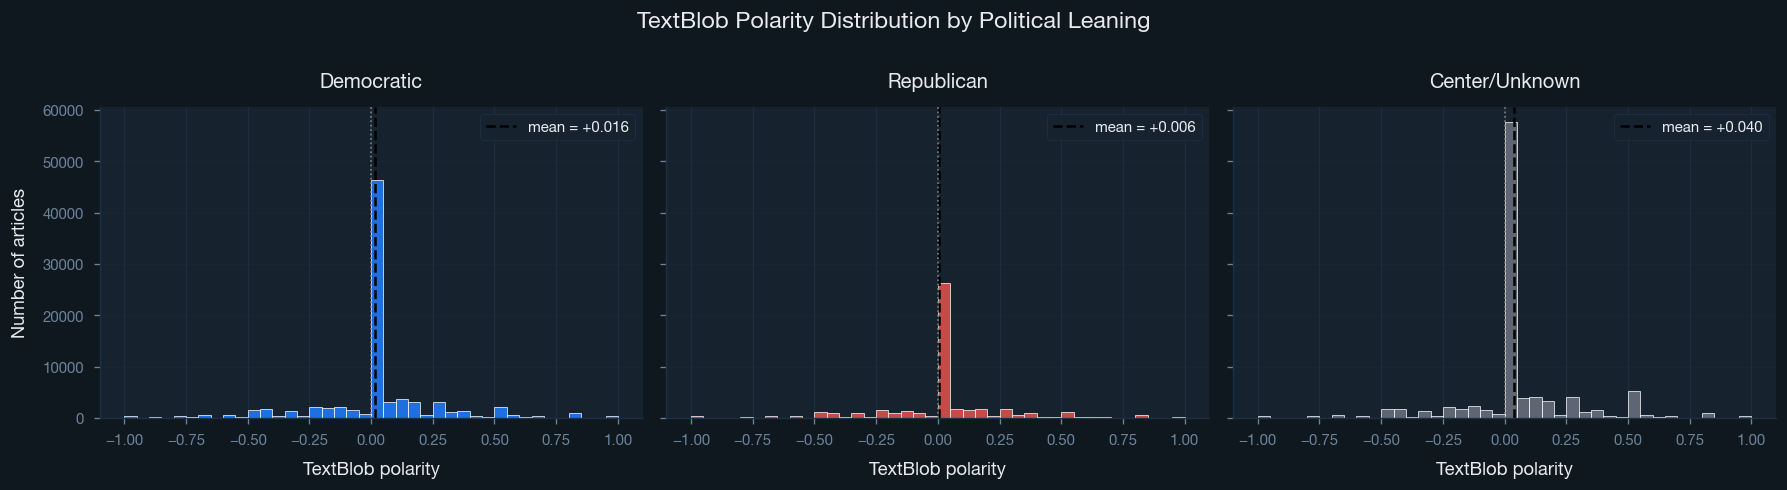

In [14]:
# ── Distribution of TextBlob polarity by leaning ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (leaning, color) in zip(axes, LEANING_COLORS.items()):
    sub = df[df['leaning'] == leaning]['tb_polarity']
    ax.hist(sub, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(sub.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'mean = {sub.mean():+.3f}')
    ax.axvline(0, color='grey', linestyle=':', linewidth=1)
    ax.set_title(leaning, fontsize=12, fontweight='bold')
    ax.set_xlabel('TextBlob polarity')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Number of articles')
fig.suptitle('TextBlob Polarity Distribution by Political Leaning',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


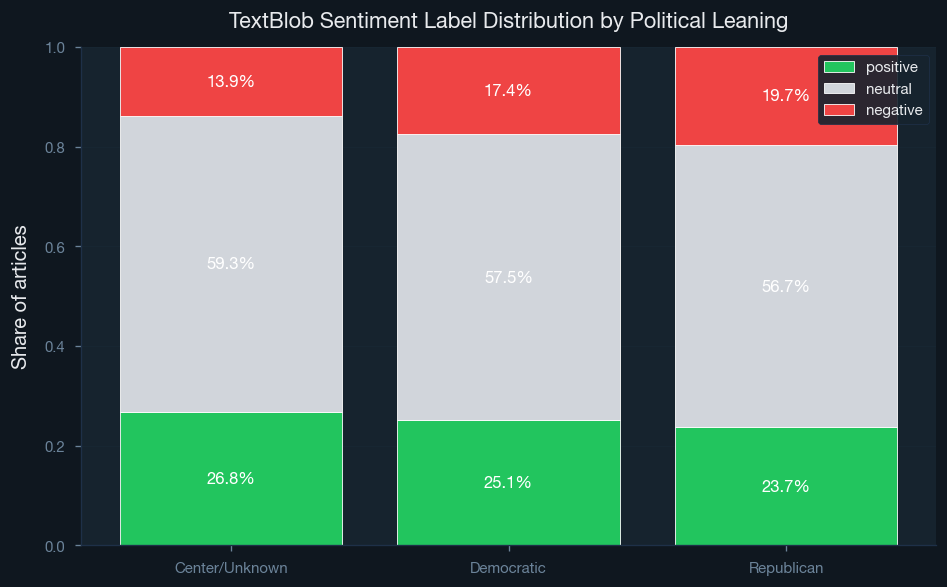

In [15]:
# ── Sentiment label shares per leaning (stacked bar) ─────────────────────────
label_shares_tb = (
    df.groupby(['leaning', 'tb_label'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
    [['positive', 'neutral', 'negative']]
)

fig, ax = plt.subplots(figsize=(8, 5))
label_colors = {'positive': '#22C55E', 'neutral': '#D1D5DB', 'negative': '#EF4444'}
bottom = np.zeros(len(label_shares_tb))

for label, col in label_colors.items():
    values = label_shares_tb[label].values
    bars = ax.bar(label_shares_tb.index, values, bottom=bottom, color=col,
                  label=label, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        if val > 0.04:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.1%}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
    bottom += values

ax.set_ylabel('Share of articles', fontsize=12)
ax.set_title('TextBlob Sentiment Label Distribution by Political Leaning',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


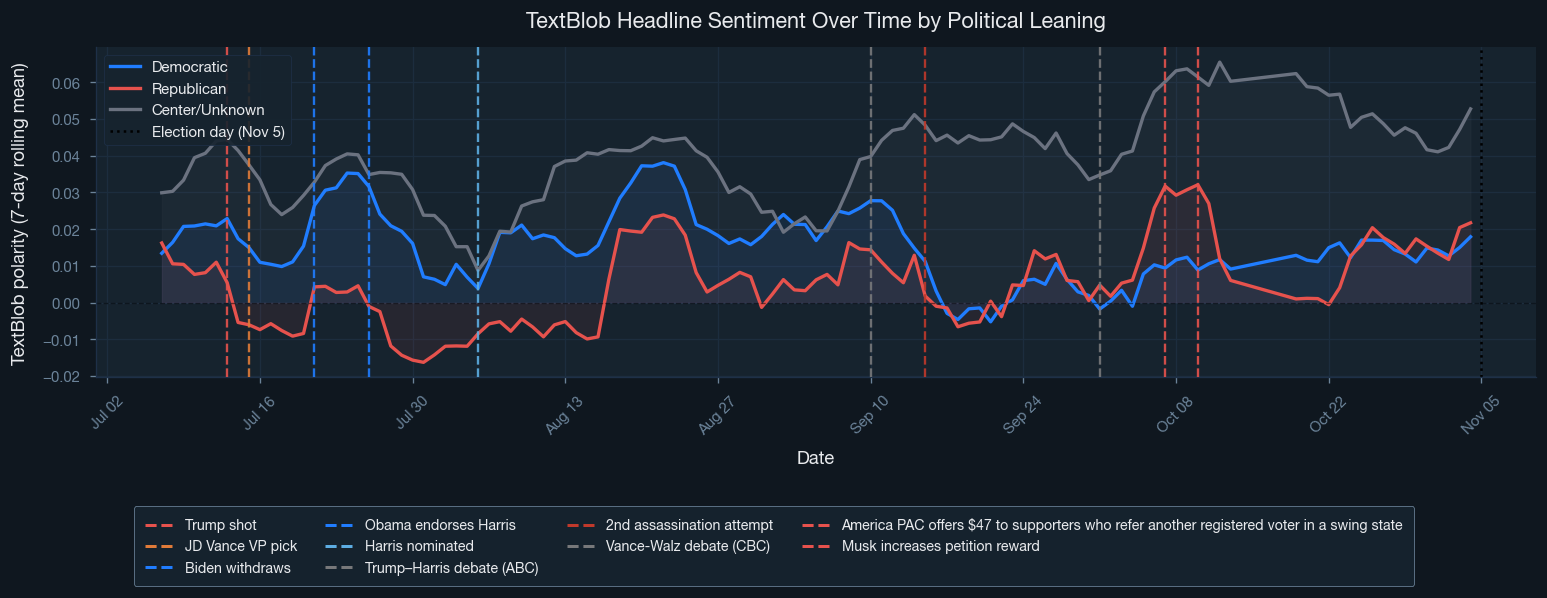

In [16]:
# ── TextBlob polarity over time (7-day rolling mean) ─────────────────────────
daily_tb = (
    df.groupby(['date', 'leaning'])['tb_polarity']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))

for leaning, color in LEANING_COLORS.items():
    sub = daily_tb[daily_tb['leaning'] == leaning].set_index('date')
    rolled = sub['tb_polarity'].rolling(7, min_periods=3).mean()
    ax.plot(rolled.index, rolled.values, color=color, linewidth=2, label=leaning)
    ax.fill_between(rolled.index, rolled.values, 0, color=color, alpha=0.08)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
add_events(ax)
ax.axvline(pd.Timestamp('2024-11-05'), color='black', linestyle=':',
           linewidth=1.5, label='Election day (Nov 5)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('TextBlob polarity (7-day rolling mean)', fontsize=11)
ax.set_title('TextBlob Headline Sentiment Over Time by Political Leaning',
             fontsize=13, fontweight='bold')
import matplotlib.lines as mlines
data_handles = ax.get_legend_handles_labels()
event_handles = [
    mlines.Line2D([], [], color=c, linestyle='--', linewidth=1.8, label=lbl)
    for lbl, _, c in EVENTS
]
ax.legend(handles=data_handles[0], labels=data_handles[1], loc='upper left')
fig.legend(
    handles=event_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    ncol=min(len(EVENTS), 4),
    facecolor=BG_PANEL, edgecolor=TEXT_MUTED, labelcolor=TEXT_PRIMARY,
    fontsize=8.5, framealpha=0.95, borderpad=0.8,
)
plt.tight_layout(rect=[0, 0.18, 1, 1])
plt.show()


---
## 5. NRCLex — Emotion Detection

NRCLex maps words to eight primary emotions (Plutchik's wheel) plus positive/negative affect.
Each score is the fraction of emotionally-tagged words in the headline matching that emotion.

**Applied to:** article headlines (`title` column).

In [23]:
EMOTIONS = ['fear', 'anger', 'anticipation', 'trust',
            'surprise', 'sadness', 'disgust', 'joy']

def nrc_scores(text):
    """Return NRCLex affect frequencies for a headline (8 emotions + pos/neg)."""
    freq = NRCLex(str(text)).affect_frequencies
    return {e: freq.get(e, 0.0) for e in EMOTIONS + ['positive', 'negative']}

print('Running NRCLex on all headlines ...')
nrc_df = df['title_clean'].apply(nrc_scores).apply(pd.Series)

for col in nrc_df.columns:
    df[f'nrc_{col}'] = nrc_df[col].values

df['nrc_sentiment'] = df['nrc_positive'] - df['nrc_negative']
nrc_cols = [f'nrc_{e}' for e in EMOTIONS]
print('Done.  Sample output:')
df[['title'] + nrc_cols].head(4)

Running NRCLex on all headlines ...
Done.  Sample output:


,title,nrc_fear,nrc_anger,nrc_anticipation,nrc_trust,nrc_surprise,nrc_sadness,nrc_disgust,nrc_joy
0,5 candidates who could replace Biden as 2024 D...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0
1,Democrats are setting up Trump for an economic...,0.142857,0.142857,0.0,0.0,0.285714,0.142857,0.142857,0.0
2,"What it’s like to be audited by the bigger, be...",0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0
3,5 takeaways from President Biden’s July campai...,0.000000,0.000000,0.0,0.5,0.000000,0.000000,0.000000,0.0


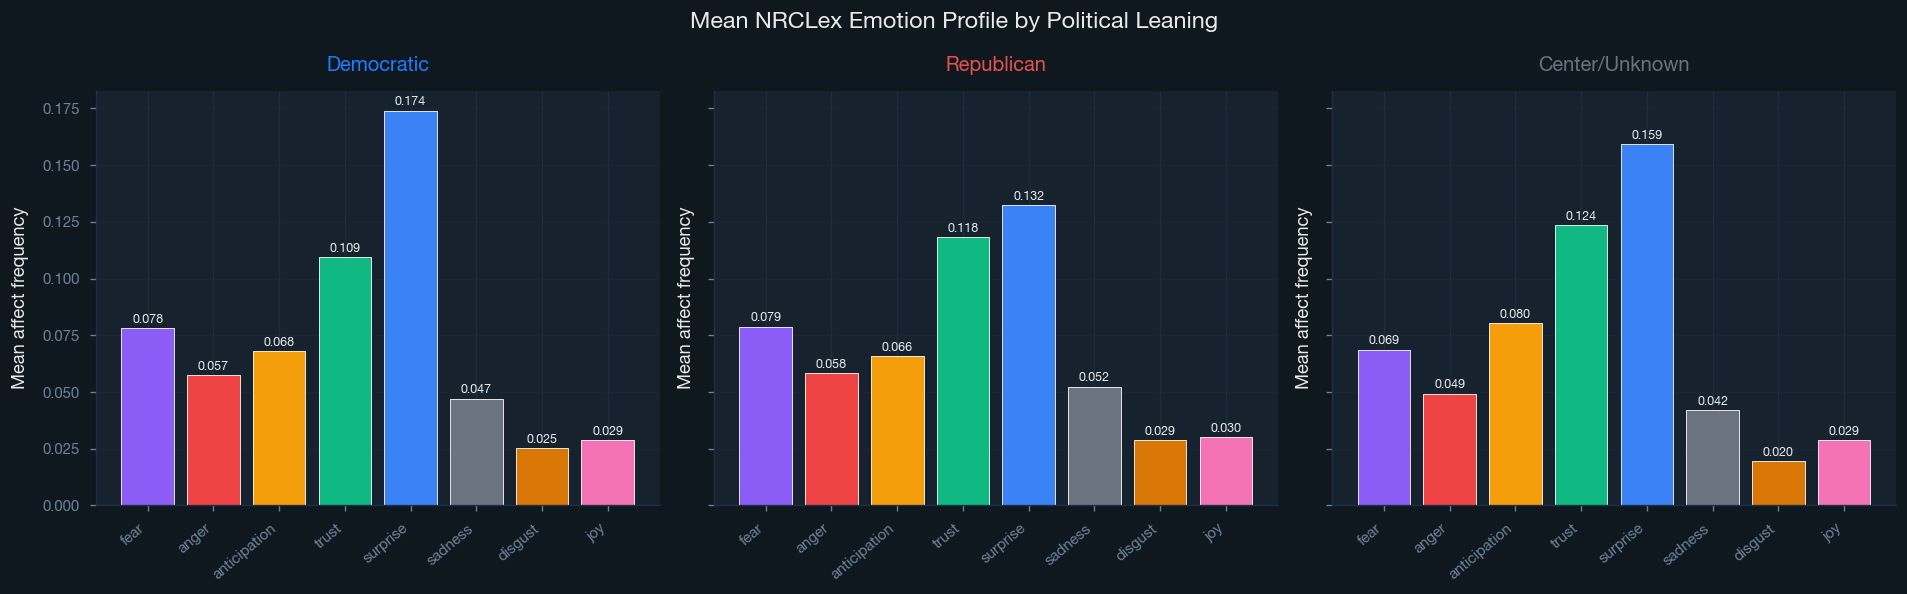

In [24]:
# ── Mean emotion profile per leaning ──────────────────────────────────────────
EMOTION_COLORS = {
    'fear': '#8B5CF6', 'anger': '#EF4444', 'anticipation': '#F59E0B',
    'trust': '#10B981', 'surprise': '#3B82F6', 'sadness': '#6B7280',
    'disgust': '#D97706', 'joy': '#F472B6',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (leaning, lean_color) in zip(axes, LEANING_COLORS.items()):
    sub = df[df['leaning'] == leaning]
    means = sub[[f'nrc_{e}' for e in EMOTIONS]].mean()
    means.index = EMOTIONS

    colors = [EMOTION_COLORS[e] for e in EMOTIONS]
    bars = ax.bar(EMOTIONS, means.values, color=colors, edgecolor='white', linewidth=0.5)

    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_title(leaning, fontsize=12, fontweight='bold', color=lean_color)
    ax.set_xticklabels(EMOTIONS, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('Mean affect frequency')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Mean NRCLex Emotion Profile by Political Leaning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

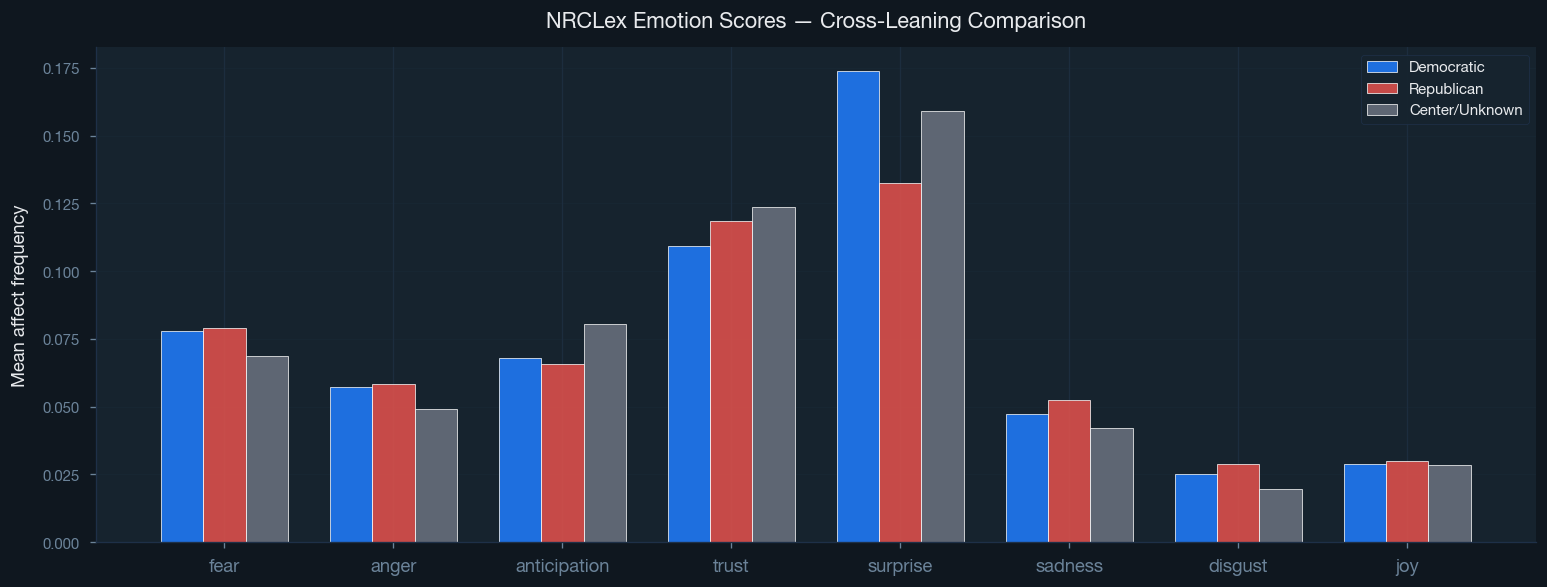


Mean emotion scores by leaning:
leaning       Center/Unknown  Democratic  Republican
fear                  0.0687      0.0780      0.0788
anger                 0.0493      0.0574      0.0584
anticipation          0.0804      0.0681      0.0658
trust                 0.1235      0.1093      0.1184
surprise              0.1592      0.1740      0.1323
sadness               0.0420      0.0471      0.0523
disgust               0.0196      0.0253      0.0288
joy                   0.0286      0.0288      0.0301


In [25]:
# ── Cross-leaning comparison for each emotion ────────────────────────────────
emotion_means = (
    df.groupby('leaning')[[f'nrc_{e}' for e in EMOTIONS]]
    .mean().T
)
emotion_means.index = EMOTIONS

x = np.arange(len(EMOTIONS))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, (leaning, color) in enumerate(LEANING_COLORS.items()):
    offset = (i - 1) * width
    ax.bar(x + offset, emotion_means[leaning], width,
           label=leaning, color=color, edgecolor='white', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(EMOTIONS, fontsize=11)
ax.set_ylabel('Mean affect frequency', fontsize=11)
ax.set_title('NRCLex Emotion Scores — Cross-Leaning Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nMean emotion scores by leaning:')
print(emotion_means.round(4).to_string())

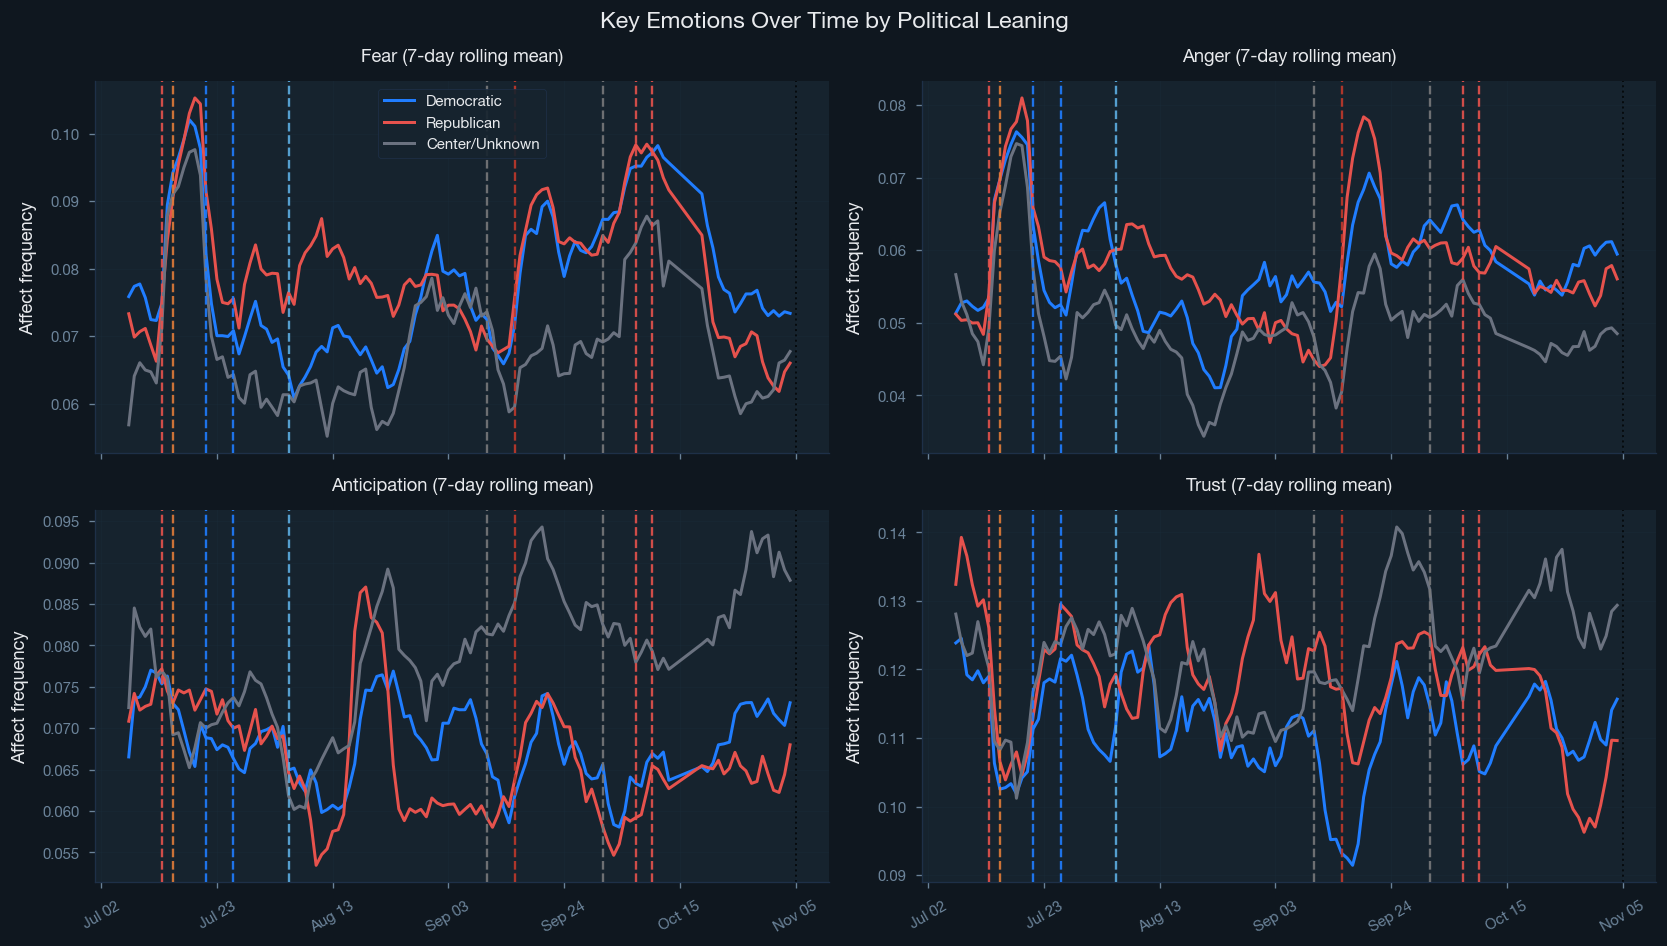

In [26]:
# ── Key emotions over time (7-day rolling mean) ─────────────────────────────
TRACK_EMOTIONS = ['fear', 'anger', 'anticipation', 'trust']

daily_nrc = (
    df.groupby(['date', 'leaning'])[[f'nrc_{e}' for e in TRACK_EMOTIONS]]
    .mean().reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, emotion in zip(axes.flat, TRACK_EMOTIONS):
    col = f'nrc_{emotion}'
    for leaning, color in LEANING_COLORS.items():
        sub = (
            daily_nrc[daily_nrc['leaning'] == leaning]
            .set_index('date')[col]
            .rolling(7, min_periods=3).mean()
        )
        ax.plot(sub.index, sub.values, color=color, linewidth=1.8, label=leaning)

    add_events(ax)
    ax.axvline(pd.Timestamp('2024-11-05'), color='black', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.set_title(f'{emotion.capitalize()} (7-day rolling mean)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Affect frequency')
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=3))

axes[0][0].legend(fontsize=9)
for ax in axes[1]:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

fig.suptitle('Key Emotions Over Time by Political Leaning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Method Comparison

Correlation between VADER, TextBlob, and NRCLex sentiment scores and a z-scored overlay.

In [27]:
sent_cols = {
    'VADER':    'vader_compound',
    'TextBlob': 'tb_polarity',
    'NRCLex':   'nrc_sentiment',
}
corr = (
    df[[v for v in sent_cols.values()]]
    .rename(columns={v: k for k, v in sent_cols.items()})
    .corr()
)
print('Correlation matrix:')
print(corr.round(3))


Correlation matrix:
          VADER  TextBlob  NRCLex
VADER     1.000     0.409   0.344
TextBlob  0.409     1.000   0.196
NRCLex    0.344     0.196   1.000


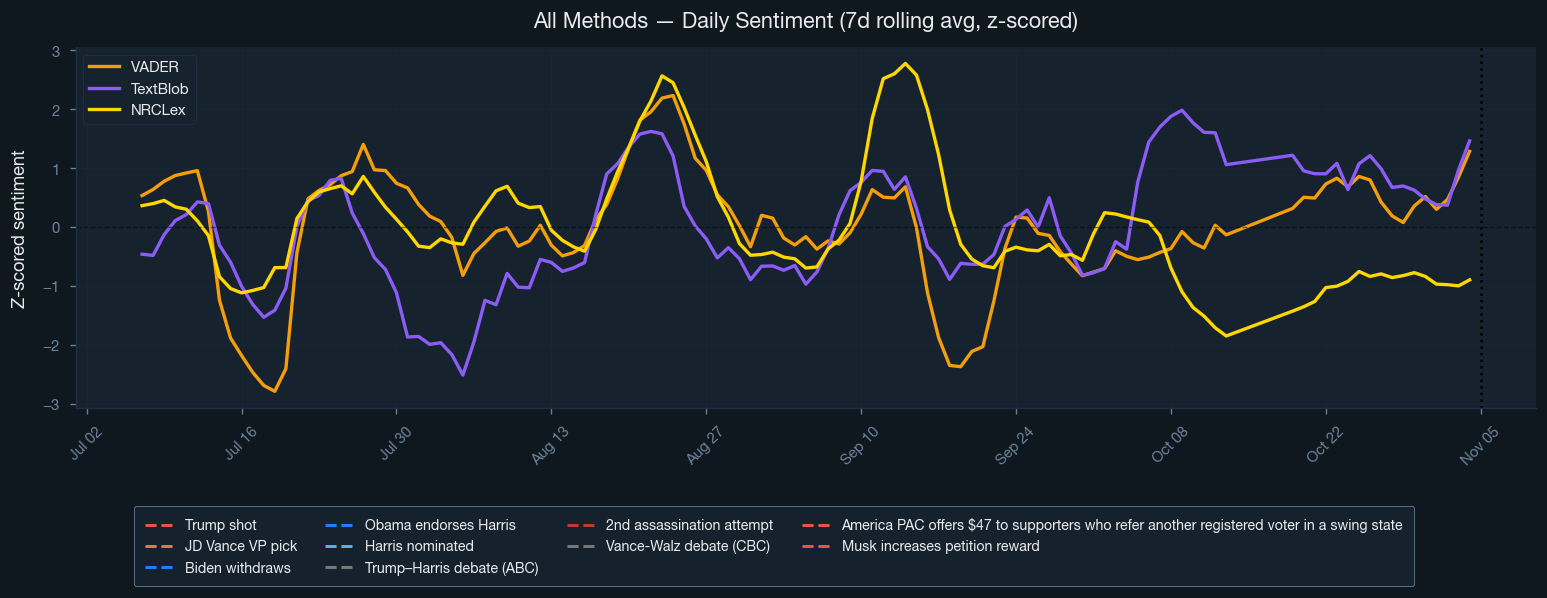

In [28]:
METHOD_COLORS = {'VADER': '#F59E0B', 'TextBlob': '#8B5CF6', 'NRCLex': '#FFD700'}

fig, ax = plt.subplots(figsize=(13, 5))

for label, col in sent_cols.items():
    daily = df.groupby('date')[col].mean()
    roll  = daily.rolling(7, min_periods=3).mean()
    z     = (roll - roll.mean()) / (roll.std() + 1e-8)
    ax.plot(z.index, z.values, linewidth=2, label=label, color=METHOD_COLORS[label])

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
import matplotlib.lines as mlines
data_handles = ax.get_legend_handles_labels()
event_handles = [
    mlines.Line2D([], [], color=c, linestyle='--', linewidth=1.8, label=lbl)
    for lbl, _, c in EVENTS
]
ax.legend(handles=data_handles[0], labels=data_handles[1], loc='upper left')
fig.legend(handles=event_handles, loc='lower center', bbox_to_anchor=(0.5, 0.0),
           ncol=min(len(EVENTS), 4), facecolor=BG_PANEL, edgecolor=TEXT_MUTED,
           labelcolor=TEXT_PRIMARY, fontsize=8.5, framealpha=0.95, borderpad=0.8)
ax.axvline(pd.Timestamp('2024-11-05'), color='black', linestyle=':', linewidth=1.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
ax.set_ylabel('Z-scored sentiment', fontsize=11)
ax.set_title('All Methods — Daily Sentiment (7d rolling avg, z-scored)',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout(rect=[0, 0.18, 1, 1])
plt.show()


---
## 5. Feature Engineering & Export

Aggregate **VADER** and **NRCLex** scores to **daily × leaning** features for the prediction model.

In [32]:
# ── 5a. Pivot helper ───────────────────────────────────────────────────────────────────
def pivot_leaning(long_df, value_cols):
    """Pivot daily long-format DataFrame to wide format with leaning suffixes."""
    frames = []
    for col in value_cols:
        for leaning, short in LEANING_SHORT.items():
            sub = long_df[long_df['leaning'] == leaning][['date', col]].copy()
            sub = sub.rename(columns={col: f'{col}_{short}'})
            frames.append(sub.set_index('date'))
    return pd.concat(frames, axis=1)

In [33]:
# ── VADER daily aggregations ──────────────────────────────────────────────────
df['vader_is_pos'] = (df['vader_label'] == 'positive').astype(float)
df['vader_is_neg'] = (df['vader_label'] == 'negative').astype(float)

vader_agg = (
    df.groupby(['date', 'leaning'])
    .agg(
        vader_compound_mean=('vader_compound', 'mean'),
        vader_compound_std =('vader_compound', 'std'),
        vader_pos_share    =('vader_is_pos',   'mean'),
        vader_neg_share    =('vader_is_neg',   'mean'),
    )
    .reset_index()
)

vader_wide = pivot_leaning(
    vader_agg,
    ['vader_compound_mean', 'vader_compound_std', 'vader_pos_share', 'vader_neg_share']
)

print(f'VADER feature matrix : {vader_wide.shape}')
vader_wide.head(3)


VADER feature matrix : (118, 12)


,vader_compound_mean_dem,vader_compound_mean_rep,vader_compound_mean_cen,vader_compound_std_dem,vader_compound_std_rep,vader_compound_std_cen,vader_pos_share_dem,vader_pos_share_rep,vader_pos_share_cen,vader_neg_share_dem,vader_neg_share_rep,vader_neg_share_cen
date,,,,,,,,,,,,
2024-07-05,-0.006252,-0.095265,0.001539,0.383403,0.362284,0.394119,0.285714,0.249042,0.319196,0.323185,0.383142,0.354911
2024-07-06,-0.071160,-0.098597,-0.030472,0.381046,0.342708,0.367350,0.248000,0.237705,0.258216,0.396000,0.368852,0.380282
2024-07-07,-0.027144,-0.098149,-0.013889,0.332855,0.340377,0.339416,0.219008,0.239437,0.276423,0.326446,0.464789,0.308943


In [34]:
# ── 5c. NRCLex daily aggregations ───────────────────────────────────────────────────
nrc_agg_spec = {f'nrc_{e}': (f'nrc_{e}', 'mean') for e in EMOTIONS}

nrc_agg = (
    df.groupby(['date', 'leaning'])
    .agg(**nrc_agg_spec)
    .reset_index()
)

nrc_wide = pivot_leaning(nrc_agg, [f'nrc_{e}' for e in EMOTIONS])

print(f'NRCLex feature matrix : {nrc_wide.shape}')
nrc_wide.head(3)

NRCLex feature matrix : (118, 24)


,nrc_fear_dem,nrc_fear_rep,nrc_fear_cen,nrc_anger_dem,nrc_anger_rep,nrc_anger_cen,nrc_anticipation_dem,nrc_anticipation_rep,nrc_anticipation_cen,nrc_trust_dem,...,nrc_surprise_cen,nrc_sadness_dem,nrc_sadness_rep,nrc_sadness_cen,nrc_disgust_dem,nrc_disgust_rep,nrc_disgust_cen,nrc_joy_dem,nrc_joy_rep,nrc_joy_cen
date,,,,,,,,,,,,,,,,,,,,,
2024-07-05,0.075492,0.079265,0.071929,0.050886,0.058202,0.064326,0.076622,0.061289,0.093458,0.102273,...,0.126569,0.043944,0.054356,0.054656,0.017388,0.020780,0.018325,0.029121,0.018947,0.025990
2024-07-06,0.087288,0.055786,0.049642,0.069811,0.055488,0.061040,0.056615,0.061865,0.049850,0.097377,...,0.112551,0.052685,0.054027,0.038260,0.031859,0.033739,0.012245,0.022417,0.041260,0.015582
2024-07-07,0.064795,0.084897,0.049039,0.033229,0.039853,0.044505,0.066360,0.089374,0.074156,0.171971,...,0.118497,0.043715,0.067355,0.039545,0.015483,0.015202,0.011558,0.023960,0.017474,0.017533


In [35]:
# ── Combine & save ───────────────────────────────────────────────────────────
sentiment_features = (
    vader_wide
    .join(nrc_wide, how='outer')
    .sort_index()
    .reset_index()
)

out_path = SILVER / 'sentiment_features_newspapers.csv'
sentiment_features.to_csv(out_path, index=False)

n_feat = sentiment_features.shape[1] - 1
print(f'Saved  -> {out_path}')
print(f'Shape  : {sentiment_features.shape}  ({n_feat} features + date)')
print(f'Dates  : {sentiment_features["date"].min().date()} -> {sentiment_features["date"].max().date()}')
print(f'\nFeature groups:')
print(f'  VADER  (compound mean, std, pos/neg share) x 3 leanings : {4 * 3:>3} columns')
print(f'  NRCLex (8 emotions x mean) x 3 leanings                 : {8 * 3:>3} columns')
print(f'  Total (excl. date)                                       : {n_feat:>3} columns')

sentiment_features.head(3)


Saved  -> ../../Data/2_Silver/Newspapers/sentiment_features_newspapers.csv
Shape  : (118, 37)  (36 features + date)
Dates  : 2024-07-05 -> 2024-11-04

Feature groups:
  VADER  (compound mean, std, pos/neg share) x 3 leanings :  12 columns
  NRCLex (8 emotions x mean) x 3 leanings                 :  24 columns
  Total (excl. date)                                       :  36 columns


,date,vader_compound_mean_dem,vader_compound_mean_rep,vader_compound_mean_cen,vader_compound_std_dem,vader_compound_std_rep,vader_compound_std_cen,vader_pos_share_dem,vader_pos_share_rep,vader_pos_share_cen,...,nrc_surprise_cen,nrc_sadness_dem,nrc_sadness_rep,nrc_sadness_cen,nrc_disgust_dem,nrc_disgust_rep,nrc_disgust_cen,nrc_joy_dem,nrc_joy_rep,nrc_joy_cen
0,2024-07-05,-0.006252,-0.095265,0.001539,0.383403,0.362284,0.394119,0.285714,0.249042,0.319196,...,0.126569,0.043944,0.054356,0.054656,0.017388,0.020780,0.018325,0.029121,0.018947,0.025990
1,2024-07-06,-0.071160,-0.098597,-0.030472,0.381046,0.342708,0.367350,0.248000,0.237705,0.258216,...,0.112551,0.052685,0.054027,0.038260,0.031859,0.033739,0.012245,0.022417,0.041260,0.015582
2,2024-07-07,-0.027144,-0.098149,-0.013889,0.332855,0.340377,0.339416,0.219008,0.239437,0.276423,...,0.118497,0.043715,0.067355,0.039545,0.015483,0.015202,0.011558,0.023960,0.017474,0.017533


In [36]:
# ── 5e. Coverage check ────────────────────────────────────────────────────────────────
missing = sentiment_features.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print('No missing values — all dates covered for all leanings.')
else:
    print('Columns with missing values (days where a leaning had no articles):')
    print(missing.to_string())

No missing values — all dates covered for all leanings.
